In [277]:
# import sklearn
import pandas as pd
import numpy as np
# from numpy import errstate,isneginf
import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as sc

from sklearn.preprocessing import LabelEncoder
# , OneHotEncoder
from sklearn.model_selection import train_test_split
# , cross_val_score
from sklearn.model_selection import StratifiedKFold
# , StratifiedShuffleSplit

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# import xgboost as xgb
from xgboost import XGBClassifier

from timeit import default_timer as timer

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import classification_report
from tqdm import tqdm
# from tqdm import trange
from collections import Counter

from sklearn.decomposition import PCA

import time

#import umap

# import zipfile
import os
import argparse
# import json
# import requests
# import io
# import copy
#import biomart
#import umap


~30 seconds to read TCGA data, ~7 seconds to read STMFR data

In [270]:
model_name = "XGB"
n_models = 100
frac_agree = 0.8

log_file = str(n_models)+"_"+str(model_name)+"_"+str(frac_agree)+"_Dec.log"

import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG) # process everything, even if everything isn't printed

fh = logging.FileHandler(log_file)
fh.setLevel(logging.DEBUG) # or any level you want
logger.addHandler(fh)

In [252]:
# log_file

str(frac_agree)

'0.9'

In [151]:
# def parseArguments():
#     # Create argument parser
#     parser = argparse.ArgumentParser()

#     # Positional mandatory arguments
#     parser.add_argument("-sfg","--save_fig_path", help="Absolute folder location to save the plots", type=str)

#     # Parse arguments
#     args = parser.parse_args()

#     return args


# if __name__ == '__main__':
#     # Parse the arguments
#     args = parseArguments()
#     save_fig_path = args.__dict__['save_fig_path']

# # Check whether the specified path exists or not
# isExist = os.path.exists(save_fig_path)
# if not isExist:

#    # Create a new directory because it does not exist
#    os.makedirs(save_fig_path)
#    print("The new directory ", save_fig_path, "is created!")


# #On bhavesh local machine
# tcga_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/tcga_final_data.csv'

# #On lab machine
# #tcga_file_path = '/home/swapnanil_mukherjee/cancer_data/tcga_final_data.csv'

# #On HPC
# #tcga_file_path = '/storage/bhavesh.neekhra_phd18/model_agreement_expr/tcga_final_data.csv'


# #On bhavesh local machine
# stmfr_file_path = '/home/bhavesh/Documents/PhD/model_agreement_expr/stmfr_4_classes.csv'

# #On lab machine
# #stmfr_file_path = '/home/bhavesh/Documents/PhD/model_agreement_expr/stmfr_4_classes.csv'

# #Works only when Google Drive is mounted on lab machine
# ## stmfr_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/stmfr_4_classes.csv'

# #On HPC
# #stmfr_file_path = '/storage/bhavesh.neekhra_phd18/model_agreement_expr/stmfr_4_classes.csv'



In [152]:
tcga_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/tcga_final_data.csv'

# tcga_file_path = '/home/swapnanil_mukherjee/cancer_data/tcga_final_data.csv'

tcga = pd.read_csv(tcga_file_path)

In [153]:
# stmfr_file_path = '/home/bhavesh/Documents/PhD/model_agreement_expr/stmfr_4_classes.csv'

stmfr_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/stmfr_4_classes.csv'
df= pd.read_csv(stmfr_file_path)

# print(df.shape)


df.set_index(df.loc[:, '0'], inplace=True)
df.drop('0', axis=1, inplace=True)

In [154]:
tcga.set_index(tcga.loc[:, "Unnamed: 0"], inplace=True)
tcga.drop("Unnamed: 0", axis=1, inplace=True)
cols = df.columns.tolist()
cols_ = cols[:-1]

tcga = tcga[cols_]

In [259]:
df.shape, tcga.shape

((3294, 11981), (11070, 11980))

In [156]:
# print(df['label'].value_counts())

In [157]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.label)
df.drop('label', axis=1, inplace=True)

In [260]:
logging.info("Class wise distribution on original dataset")
logging.info(df['numeric_label'].value_counts())
logging.info(label_encoder.classes_)

In [254]:
def get_model(model_name):
  model_dict = {'Logistic Regression':LogisticRegression(n_jobs=-1, max_iter=250),
                'LR':LogisticRegression(n_jobs=-1, max_iter=250),

                'SVM':LinearSVC(dual = True, max_iter=10000),

                'Decision Tree':DecisionTreeClassifier(min_samples_split=16, min_samples_leaf=3, max_depth= 15, criterion= 'entropy'),
                'DT':DecisionTreeClassifier(min_samples_split=16, min_samples_leaf=3, max_depth= 15, criterion= 'entropy'),

                'Random Forest':RandomForestClassifier(n_estimators=10),
                'RF':RandomForestClassifier(n_estimators=10),

                "Neural Network":MLPClassifier(hidden_layer_sizes=[512, 256], solver='sgd', batch_size=256, max_iter=100),
                "NN":MLPClassifier(hidden_layer_sizes=[512, 256], solver='sgd', batch_size=256, max_iter=100),
                
                "XGBoost": XGBClassifier(num_class=4, objective='multi:softmax'),
                "XGB": XGBClassifier(num_class=4, objective='multi:softmax')
                }
  model_name = model_name.strip()

  if model_name not in model_dict:
    print("Model name should be one of", list(model_dict.keys()))
    print("Please check the entered model name for spelling errors.")
    exit

  else:
    model = model_dict[model_name]
    return model

In [160]:
# plt.rcParams.update({'font.size': 8})

In [261]:
global box_plot_num 
box_plot_num = 0
global model_prediction_agreement 
model_prediction_agreement = 0

In [218]:
# Creating plot
# plt.boxplot(model_acc_list, patch_artist = True,
#                 notch ='True', vert = 0)
def box_plot_models_accuracy(model_acc_list):

    global box_plot_num
    # fig = plt.figure(figsize =(6, 4))    
    plt.boxplot(model_acc_list, vert = 0, )
    
    plt.xlabel("accuracy")
    # plt.title('PCA with 500 components\n 90-10 data split')   # Change the font setting for the title 
    fname = model_name+'_boxplot_'+str(box_plot_num)+'.png'
    box_plot_num = box_plot_num + 1
    plt.savefig(fname)
    plt.close()


In [276]:
def get_agreement_rate(model_pred, n_models, len_tcga, frac_agree):

    model_pred_results = pd.DataFrame(model_pred)
    # model_pred_results.to_csv("model_agreements.csv", index=False)
    len_model_pred_results = len(model_pred_results.columns)
    min_agree_list = []

    count_models = n_models # For prototyping use 5, and change it back to 100
    samples_index = []

    low = np.int16(np.ceil(0.4*count_models))
    high = int(count_models*frac_agree) + 1

    # for min in range(40,101):
    for min in range(low,high):     
        c = 0
        for i in range(len_model_pred_results):
            counter_values = list(Counter(model_pred_results[i]).values())
            if any(j >= min for j in counter_values):
                c+=1
                if(min == count_models*frac_agree):
                    samples_index.append([i, model_pred_results[i][0]])
                    # print (i, model_pred_results[i])
        agree_score = c/len_tcga
        min_agree_list.append([min, agree_score])

    min_agree_df = pd.DataFrame(min_agree_list)
    logger.info("No of samples for which all models agreed: %d", len(samples_index))
    # logger.info(len(samples_index))
    return samples_index, min_agree_df

In [267]:
if(90 == 100*0.9):
    print ("Yes")
else:
    print("No")

Yes


In [274]:
100*.9

90.0

In [220]:
def plot_model_accuracy(min_agree_df, len_train, len_test, len_ood):

    global model_prediction_agreement
    x = min_agree_df[0]
    y = min_agree_df[1]

    # make data
    # x = np.linspace(0, 10, 100)
    # y = 4 + 2 * np.sin(2 * x)

    # plot
    fig, ax = plt.subplots()

    ax.plot(x, y, linewidth=2.0)

    # ax.set(xlim=(0, 100),
    #        ylim=(0, 1.1),)

    for i,j in zip(x,y):
        if(i in (40, 60, 70, 80, 90, 100)):
            ax.annotate(f"{j:.1%}",xy=(i,j))


    ax.set(ylim=(0, 1.1))
    plt.xlabel('Number of models')
    plt.ylabel('% agreement')
    plt.title('Train: '+str(len_train)+' Test: '+str(len_test)+' OOD: '+str(len_ood))
    fname = model_name+'_model_agreement_percent_'+str(model_prediction_agreement)+'.png'
    model_prediction_agreement = model_prediction_agreement + 1
    plt.savefig(fname)
    plt.close()

In [221]:
def merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df):
    
    samples_index_df = pd.DataFrame(samples_index)
    # samples_index_df
    selected_tcga_samples = tcga_df.iloc[samples_index_df[0]]
    
    ood_index = list(set(range(len(tcga_df))) - set(samples_index_df[0]))
    
    ood_tcga_samples = tcga_df.iloc[ood_index]

    selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])


    combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples])
    return combined_train_stmfr_tcga, "", ood_tcga_samples
    
    # if len(selected_tcga_samples) == 1:
    #     combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples])
    #     return combined_train_stmfr_tcga, "", ood_tcga_samples
    # else:
    #     selected_tcga_samples_train, selected_tcga_samples_test = train_test_split(selected_tcga_samples, test_size=0.2, random_state=42, shuffle=True) 
    #     combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples_train])
    #     return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [166]:
# !pip install hyperopt

In [167]:
# import hyperopt.pyll.stochastic

# print(hyperopt.pyll.stochastic.sample(space))

In [224]:
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

X_train, y_train = train.iloc[:, :-1], train['numeric_label']
X_test, y_test = test.iloc[:, :-1], test['numeric_label']

model = DecisionTreeClassifier(random_state=42)

params = {'max_depth':[3, 5, 7, 10, 15],
          'min_samples_leaf':[3, 5, 10, 15,20],
          'min_samples_split':[8, 10, 12, 16, 18, 20],
          'criterion':['gini','entropy']}
RS_DT = RandomizedSearchCV(estimator=model, param_distributions=params, cv=5, n_iter=300, n_jobs=-1, verbose=True, scoring='accuracy')

RS_DT.fit(X_train, y_train)
# import xgboost as xgb
# from hyperopt import fmin, tpe, hp
# from hyperopt import STATUS_OK

# # Define the hyperparameter space
# space = {
#     'max_depth': hp.uniformint('max_depth', 2, 8),
#     'learning_rate': hp.loguniform('learning_rate', -5, -2),
#     'subsample': hp.uniform('subsample', 0.5, 1)
# }

# train, test = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)

# # train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# # Define the objective function to minimize
# def objective(params):
#     xgb_model = xgb.XGBClassifier(**params)
#     xgb_model.fit(X_train, y_train)
#     y_pred = xgb_model.predict(X_test)
#     score = accuracy_score(y_test, y_pred)
#     return {'loss': -score, 'status': STATUS_OK}

# # Perform the optimization
# best_params = fmin(objective, space, algo=tpe.suggest, max_evals=10)
# print("Best set of hyperparameters: ", best_params)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=300, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, 15],
                                        'min_samples_leaf': [3, 5, 10, 15, 20],
                                        'min_samples_split': [8, 10, 12, 16, 18,
                                                              20]},
                   scoring='accuracy', verbose=True)

hyperopt with 10 evaluations, for XGBoost, Best set of hyperparameters:  {'learning_rate': 0.11716612264320947, 'max_depth': 4.0, 'subsample': 0.8195573834624639}
                                                            
                                                            default: eta [default=0.3, alias: learning_rate], max_depth [default=6], subsample [default=1] 
                                                                        (Source: https://xgboost.readthedocs.io/en/release_0.82/parameter.html)

In [236]:
print("Best Parameters:", RS_DT.best_params_,end='\n\n')
print("Best Score:", RS_DT.best_score_)

Best Parameters: {'min_samples_split': 16, 'min_samples_leaf': 3, 'max_depth': 15, 'criterion': 'entropy'}

Best Score: 0.869449715370019


For Decision Tree, RandomizedSearchCV

Best Parameters: {'min_samples_split': 16, 'min_samples_leaf': 3, 'max_depth': 15, 'criterion': 'entropy'}

Defatul Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}

Best Score: 0.869449715370019

In [233]:
accuracy_score(y_test, RS_DT.predict(X_test))

0.8755690440060698

In [238]:
 # import warnings
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")   /. 

# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# train, test = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)

# train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

def check_model_stmfr():
        
    x = df.iloc[:, :-1]
    y = df['numeric_label']

    # scaler = StandardScaler()

    # x_rescaled = pd.DataFrame(scaler.fit_transform(x), index=x.index, columns=x.columns)

    acc_list = []
    b_acc_list = []
    f1_list = []
    prec_list = []
    rec_list = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_index, test_index in skf.split(x, y):
        
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
        
        # model = get_model(model_name)
        model = DecisionTreeClassifier(min_samples_split=16, min_samples_leaf=3, max_depth= 15, criterion= 'entropy')
        # model = XGBClassifier(num_class=4, objective='multi:softmax')  #, max_depth=4, learning_rate=0.117, subsample=0.82)

        # model = LogisticRegression(n_jobs=-1, max_iter=250)
        
        # pca = PCA(n_components=0.99)
        # X_train_pca = pca.fit_transform(X_train)
        # X_test_pca = pca.transform(X_test)

        # fit model
        model.fit(X_train, y_train)
        # make predictions
        predictions = model.predict(X_test)

        # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # dtrain.save_binary('train.buffer')

        # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        # param['nthread'] = 4
        # param['eval_metric'] = 'auc'
        # param['num_class'] = 4

        # num_round = 10
        # bst = xgb.train(param, dtrain, num_round)

        # dtest = xgb.DMatrix(X_test_pca)
        # predictions = bst.predict(dtest)

        # target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
        # print(classification_report(y_test, predictions, target_names=target_names))

        # model_acc = accuracy_score(y_test, predictions, normalize=True)
        # model_acc

        accuracy = accuracy_score(y_test, predictions)
        acc_list.append(accuracy)

        b_accuracy = balanced_accuracy_score(y_test, predictions)
        b_acc_list.append(b_accuracy)

        f1score = f1_score(y_test, predictions, average='weighted')
        f1_list.append(f1score)

        precision = precision_score(y_test, predictions, average='weighted')
        prec_list.append(precision)

        recall = recall_score(y_test, predictions, average='weighted')
        rec_list.append(recall)

        print(accuracy, end='\t')
        print(b_accuracy, end='\t')
        print(f1score, end='\t')
        print(precision, end='\t')
        print(recall)

        # break

    print("Average for 5-fold cross-validation:\n")

    print("Accuracy: ", np.average(acc_list), end='\t')
    print("Balanced Accuracy: ", np.average(b_acc_list), end='\t')
    print("F1 score: ", np.average(f1_list), end='\t')
    print("Precision: ", np.average(prec_list), end='\t')
    print("Recall: ", np.average(rec_list))
        # xgb.plot_importance(bst)
        # xgb.plot_tree(bst, num_trees=2)
        # xgb.to_graphviz(bst, num_trees=2)

Source: https://mikulskibartosz.name/pca-how-to-choose-the-number-of-components 

For PCA = variance required

Default setting of XGBoost (What is it for n_estimators (100?), max_depth (3?), learning rate (?)

Max depth = 20, 90/10
with all features Xgboost acc = 94.55
with 100 PCA , 0.9363636363636364 , 0.9545454545454546 , 0.9575757575757575, 0.9515151515151515
with 55 PCA, 0.9424242424242424


70/30

100 PCA , 0.9332659251769464 , 0.9362992922143579 

Max depth = 20, 70/30, w/o PCA,0.9433771486349848, 2m 34.2s
Max depth = 20, 70/30, 100 PCA,0.9332659251769464, 58.2s, 0.9322548028311426(45.0s)

In [239]:
# tcga
check_model_stmfr()


0.8634294385432474	0.8525897883357955	0.863143983501668	0.8636893129977832	0.8634294385432474
0.8922610015174507	0.8860898878609746	0.8919612988010825	0.8919996615499722	0.8922610015174507
0.8573596358118362	0.851407860550436	0.8577841673245168	0.8591820837489142	0.8573596358118362
0.8649468892261002	0.8556019274970627	0.864663120013018	0.8650914038169342	0.8649468892261002
0.8647416413373861	0.8568564305844376	0.8648796325172974	0.865044943401818	0.8647416413373861
Average for 5-fold cross-validation:

Accuracy:  0.868547721287204	Balanced Accuracy:  0.8605091789657413	F1 score:  0.8684864404315163	Precision:  0.8690014811030844	Recall:  0.868547721287204


Default DT on STMFR

0.8679817905918058	0.8580144133550927	0.8674333245540867	0.8671897067674726	0.8679817905918058

0.8801213960546282	0.8684092785881865	0.8794070838121345	0.879206748287741	0.8801213960546282

0.8619119878603946	0.8611241916606627	0.8622920460212726	0.8635377529870443	0.8619119878603946

0.8831562974203339	0.8752958891515941	0.8826011778450076	0.8829919950745394	0.8831562974203339

0.8768996960486323	0.8711173085436268	0.8769341574013189	0.8771383272601282	0.8768996960486323

Average for 5-fold cross-validation:

Accuracy:  0.8740142335951588	Balanced Accuracy:  0.8667922162598325	F1 score:  0.873733557926764	Precision:  0.8740129060753852	Recall:  0.8740142335951588

in vim:

%s/findfont:.*\n//gc

In [262]:
def prediction_agreement_models(stmfr_df, tcga_df, held_out_data = "", n_models = 100, frac_agree = 1, pca = False, pca_n_components = 100):

    n = n_models
    model_acc_list = []
    val_acc_list = []
    model_pred = []
    df = stmfr_df
    tcga = tcga_df

    val_data = False

    # pca_n_comps = [1, 5, 10, 50, 100, 500, 1000, 2000]
    # pca_n_comps = [200, 300, 400, 600, 700, 800, 900]

    for i in tqdm(range(n)):
    # for i in pca_n_comps:
        train, test = train_test_split(df, test_size=0.2, random_state=i, shuffle=True)

        # train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

        X_train, y_train = train.iloc[:, :-1], train['numeric_label']
        X_test, y_test = test.iloc[:, :-1], test['numeric_label']

        # scaler = preprocessing.StandardScaler().fit(X_train)
        # pipe = make_pipeline(StandardScaler(), LinearSVC(dual = True, max_iter=10000))
        # pipe.fit(X_train, y_train)
        # pipe.score(X_test, y_test)

        # print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
        if pca:
                
            pca = PCA(n_components=pca_n_components)
            X_train_pca = pca.fit_transform(X_train)
            X_test_pca = pca.transform(X_test)
            tcga_pca = pca.transform(tcga)
            
            # model = LinearSVC(dual = False, max_iter=10000)
        else:
            X_train_pca = X_train
            X_test_pca = X_test
            tcga_pca = tcga

            # model = LinearSVC(dual = True, max_iter=10000)
        
        if (i==0):
            logging.info(model_name)

        model =get_model(model_name)
        # model = LogisticRegression(n_jobs=-1, max_iter=250)
        
        # model_coeffs = model.coef_
        # mlp_model = MLPClassifier(hidden_layer_sizes=[10, 10], solver='sgd', batch_size=256, max_iter=100)

        # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # # dtrain.save_binary('train.buffer')

        # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        # param['nthread'] = 4
        # param['eval_metric'] = 'auc'
        # param['num_class'] = 4

        # num_round = 10
        # model = xgb.train(param, dtrain, num_round)

        # dtest = xgb.DMatrix(X_test_pca)
        # predictions = model.predict(dtest)

        model.fit(X_train_pca, y_train)
        predictions = model.predict(X_test_pca)

        try:   
            if not held_out_data.empty:
                val_data = True
                X_validation, y_validation = held_out_data.iloc[:, :-1], held_out_data['numeric_label']
                if pca:
                    X_validation_pca = pca.transform(X_validation)
                else:
                    X_validation_pca = X_validation

                # dvalid = xgb.DMatrix(X_validation_pca)
                # validation_prediction = model.predict(dvalid)
                validation_prediction = model.predict(X_validation_pca)
                validation_prediction_acc = accuracy_score(y_validation, validation_prediction, normalize=True)
                val_acc_list.append(validation_prediction_acc)
                if(i%10 == 0):
                    logger.info("For "+str(i)+" model's accuracy on heldout OOD data: "+str(validation_prediction_acc))
        except Exception as e:
            #Handle the exception
            # print("An exception occurred: ", e)
            # logging.warning("An exception occurred: ")
            # logging.warning(e) 
            pass

        # report = classification_report(y_test, predictions, output_dict=True)
        model_acc = accuracy_score(y_test, predictions, normalize=True)
        model_acc_list.append(model_acc)

        # print("For", i, "LinearSVC accuracy: ", model_acc)
        # dvalid = xgb.DMatrix(tcga_pca)
        # model_pred.append(model.predict(dvalid))

        model_pred.append(model.predict(tcga_pca))

        # model_pred.append(model.predict(stmfr_data_predict))

        # results = pd.DataFrame(report).transpose()
        # results = results.round({'precision': 2, 'recall': 2, 'f1-score': 2, 'support':1})
        # model.predict(tcga)
        

    logging.info("For "+str(n)+" models, test accuracy avg and stddev: "+str(np.mean(model_acc_list))+" "+str(np.std(model_acc_list)))
    if(val_data):
        logging.info("For "+str(n)+" models, validation accuracy (on held out OOD) avg and stddev: "+str(np.mean(val_acc_list))+" "+str(np.std(val_acc_list)))

    box_plot_models_accuracy(model_acc_list)
    samples_index, min_agree_df = get_agreement_rate(model_pred, n ,len(tcga), frac_agree)
    logging.info("No of OOD samples for which labelling is done: "+str(len(samples_index)))
    plot_model_accuracy(min_agree_df, len(X_train), len(X_test), len(tcga))
    if len(samples_index) != 0:
        combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df)
    else:
        logging.info("No agreement among models.")
        return [], [], []
    
    
    return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [278]:
start = timer()

logger.info("for model: ")
logger.info(model_name)

logger.info("Round 1 starts.")
combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(df, tcga, "", n_models=n_models, frac_agree=frac_agree)

if (len(ood_tcga_samples)!=0):
    logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
    
    tcga_curr_round_labelled = combined_train_stmfr_tcga.filter(like='TCGA', axis=0)
    # tcga_curr_round_combined = pd.concat([tcga_curr_round_labelled, selected_tcga_samples_test])
    logger.info("Labels Distribution in current round:")           
    logger.info(tcga_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count())
else:
    print ("End of code!!!")

logger.info("Round 1 ends.")
curr_round_added_samples_count = len(combined_train_stmfr_tcga) - len(df)    

end = timer()

print(end - start)

100%|██████████| 100/100 [2:49:37<00:00, 101.78s/it] 
/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_88343/3978133666.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])


4879.816520249995


In [273]:
tcga_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count()

numeric_label
0     1615
1     7293
2    73111
3      192
Name: numeric_label, dtype: int64

In [250]:
combined_train_stmfr_tcga
# selected_tcga_samples_test, 
# ood_tcga_samples

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,0
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,0
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,0
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,0
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AA-A00A-01,0.385680,-0.031823,-0.195677,-0.091003,-0.285789,-0.202349,-0.298258,-0.504521,-0.046651,-0.418999,...,-0.339206,-0.747984,0.000000,0.000000,-0.416448,0.000000,-0.243925,0.000000,-0.262887,1
TCGA-AA-A00U-01,1.003745,-0.043863,0.494475,-0.343872,0.807487,-0.300663,-0.339882,0.266057,-0.472318,-0.224375,...,-0.336986,-0.752398,0.000000,0.000000,-0.483305,0.000000,-0.835652,0.000000,-0.201228,1
TCGA-AA-A010-01,0.358395,-0.020905,0.559479,0.805184,0.177750,-0.260699,-0.323350,0.196511,-0.069541,0.115265,...,-0.336117,0.809732,0.000000,0.000000,-0.389599,0.000000,-0.159080,0.000000,-0.402395,1
TCGA-AG-3598-01,1.238699,-0.042621,0.955049,0.591036,0.581125,-0.276042,-0.331237,-0.597353,-0.621746,-0.378352,...,-0.331676,-0.009246,0.000000,0.000000,-0.691147,0.000000,-1.132862,0.000000,-0.603984,1


2m 57.8s, 3 models, 100 PCA
For 3 models, test accuracy avg and stddev:  0.9555555555555556 0.01737843488291437
Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga:  7009 929 6426

w/o PCA, 3 models 

In [251]:
round = 2
while True:
    try:
        if curr_round_added_samples_count >= 0.05*len(tcga):
            # logger.debug/info/warning/error
            logger.info("\nRound "+str(round)+" starts:\n")   
            logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))
            
            prev_round_combined_samples_count = len(combined_train_stmfr_tcga)

            combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(
                combined_train_stmfr_tcga, ood_tcga_samples, selected_tcga_samples_test, n_models=n_models, frac_agree=frac_agree)
            
            logger.info("\nRound "+str(round)+" Details:\n")   
            logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_tcga_samples_test))+" "+str(len(ood_tcga_samples)))

            curr_round_combined_samples_count = len(combined_train_stmfr_tcga)

            curr_round_added_samples_count = curr_round_combined_samples_count - prev_round_combined_samples_count

            tcga_curr_round_labelled = combined_train_stmfr_tcga.filter(like='TCGA', axis=0)
            # tcga_curr_round_combined = pd.concat([tcga_curr_round_labelled, selected_tcga_samples_test])        
            logger.info("Labels Distribution in current round:")   
            logger.info(tcga_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count())
            
            logger.info("\nRound "+str(round)+" ends.\n\n") 

            round = round + 1
            # if len(selected_tcga_samples_test*4) <= 100:
            #     logger.info("No of selected TCGA samples for next round is less than 100")
                
            #     break
        else:
            logger.info("No of samples added, %d, is less than 5%% of the original.",curr_round_added_samples_count)
            break
    except Exception as e:
        #Handle the exception
        logger.warning("An exception occurred:")
        logger.warning(e) #
        break
logger.info("Forward experiment ended in %d rounds!!!\n", round-1)    

100%|██████████| 5/5 [02:03<00:00, 24.69s/it]
/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_88343/3978133666.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])
100%|██████████| 5/5 [05:01<00:00, 60.38s/it]
/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_88343/3978133666.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])
100%|██████████|

In [175]:
len(combined_train_stmfr_tcga), len(selected_tcga_samples_test), len(ood_tcga_samples)

(14119, 0, 245)

In [176]:
# combined_train_stmfr_tcga.to_csv("combined_STMFR_TCGA_1st_round.csv")

# selected_tcga_samples_test.to_csv("selected_TCGA_1st_round.csv")

In [177]:
# Forward experiment, in each round, in labeled TCGA, plot the distribution of labels

# Saving the labelled TCGA took ~ 1m 32.4s 

tcga_labelled_forward_expr = combined_train_stmfr_tcga.filter(like='TCGA', axis=0)

# tcga_curr_round_combined = pd.concat([tcga_curr_round_labelled, selected_tcga_samples_test])
    
# fname = model_name+"_TCGA_labelled_Dec23.csv"    
# tcga_curr_round_combined.to_csv(fname)

In [178]:
# !ls /Users/bhavesh/Documents/AU/PhD/model_agreement_expr/gitrepo/model_agreement/XGB_TCGA_labelled_Dec23.csv

# Reverse Experiment
# Use TCGA to label STMFR

In [179]:
# Took 18.9s to read from local 

# tcga_labeled_df = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/gitrepo/model_agreement/XGB_TCGA_labelled_Dec23.csv")

tcga_labeled_df = tcga_labelled_forward_expr

In [180]:
logger.info("Labelled TCGA: shape %s", tcga_labeled_df.shape)
# logger.info(tcga_labeled_df.shape)
# logger.info("")

In [181]:
tcga_labeled_df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
TCGA-BA-4076-01,-0.588152,-0.051600,0.275611,-0.589297,-0.137961,-0.329927,-0.321080,-0.158018,0.008967,-0.490037,...,-0.346863,-0.405294,0.0,0.0,-0.478480,0.0,-0.664333,0.0,-0.552089,2
TCGA-BA-4077-01,-0.590541,-0.051600,-0.603677,-0.350072,0.741167,-0.025565,-0.093639,-0.639857,0.363241,-0.244988,...,-0.332242,-0.669118,0.0,0.0,-0.369545,0.0,-1.071120,0.0,-0.471678,0
TCGA-BA-4078-01,-0.311306,-0.051600,-0.672954,0.415134,1.648229,-0.104049,-0.214679,0.892278,1.755997,-0.522709,...,-0.315238,0.127023,0.0,0.0,-0.319389,0.0,0.738294,0.0,-0.391021,0
TCGA-BA-5151-01,-0.869650,-0.051600,-0.096756,-0.779369,-0.399028,-0.168793,-0.092261,-0.547559,-0.452168,-0.464442,...,-0.340580,-1.212663,0.0,0.0,-0.272984,0.0,-0.993466,0.0,-0.992499,3
TCGA-BA-5152-01,-0.022110,-0.051600,-0.296342,-1.162415,-0.350085,-0.168063,0.037124,-1.132877,-0.657968,-0.048155,...,-0.338502,-0.513802,0.0,0.0,-0.352701,0.0,-1.255349,0.0,-0.499691,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-EJ-7792-01,-0.452436,-0.049251,-0.635485,0.179077,-0.718453,-0.157448,-0.143914,-0.525095,-0.340207,0.708775,...,0.486030,-0.243063,0.0,0.0,-0.316293,0.0,0.266904,0.0,-0.948038,0
TCGA-EJ-A46D-01,0.212368,-0.028258,-0.398107,0.539183,-0.698539,-0.271402,-0.317844,-0.337340,-0.008179,1.270693,...,0.149993,1.034463,0.0,0.0,-0.585880,0.0,0.045855,0.0,-0.444466,1
TCGA-EJ-A65M-01,0.465648,-0.049983,0.273755,-0.431159,-0.672033,-0.290695,-0.323148,-0.746674,-0.016159,0.831818,...,-0.107421,-0.029374,0.0,0.0,-0.664788,0.0,-1.117124,0.0,-0.148611,0
TCGA-G9-6333-01,-0.365930,-0.039634,-0.884293,-0.423295,-0.800699,-0.277456,-0.345065,0.097894,0.607008,2.228937,...,-0.102869,0.472263,0.0,0.0,-0.208149,0.0,-0.739680,0.0,-0.484951,0


In [182]:
# tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
# tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [183]:
stmfr_unlabelled_df = df.iloc[:, :-1]

In [184]:
stmfr_unlabelled_df.shape

(3294, 11980)

In [185]:
logger.info("\n Reverse experiment: \n\n")

logger.info("\n Round 1 begins")
combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr = prediction_agreement_models(tcga_labeled_df, stmfr_unlabelled_df, "", n_models=n_models, frac_agree=frac_agree)

logger.info("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_stmfr_test))+" "+str(len(ood_stmfr)))


stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
# stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])        

logger.info(stmfr_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count())

logger.info("\n Round 1 ends")

curr_round_added_samples_count = len(combined_train_stmfr_tcga) - len(tcga_labeled_df)    

  0%|          | 0/3 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
 33%|███▎      | 1/3 [01:28<02:57, 88.67s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https

In [186]:
round = 2
while True:
    try:
        if curr_round_added_samples_count >= 0.05*len(stmfr_unlabelled_df):
            logger.info("\nRound "+str(round)+" starts:\n\n")   
            logger.info("\nLength of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_stmfr_test))+" "+str(len(ood_stmfr)))
            
            prev_round_combined_samples_count = len(combined_train_stmfr_tcga)

            #Function call 
            combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr = prediction_agreement_models(
                combined_train_stmfr_tcga, ood_stmfr, selected_stmfr_test, n_models=n_models, frac_agree=frac_agree)
            
            logger.info("\nRound "+str(round)+" details:\n\n")   
            logger.info("\nLength of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr: "+
                str(len(combined_train_stmfr_tcga))+" "+str(len(selected_stmfr_test))+" "+str(len(ood_stmfr)))
            
            curr_round_combined_samples_count = len(combined_train_stmfr_tcga)

            curr_round_added_samples_count = curr_round_combined_samples_count - prev_round_combined_samples_count

            stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
            # stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])     
            logger.info("Labels Distribution in current round:")   
            logger.info(stmfr_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count())
            
            logger.info("Round "+str(round)+" ends.")
            round = round + 1
            # if len(selected_stmfr_test)*4 <= 100:
            #     logger.info("No of selected STMFR samples for next round is less than 100")
            #     break
        else:
            logger.info("No of samples added is less than 5\% of the original %d", curr_round_added_samples_count)
            break
    except Exception as e:
        #Handle the exception
        logger.warning("An exception occurred: ")
        logger.warning(e) 
        break
logger.info("Reverse experiment ended in %d rounds!!!\n", round-1)    

  0%|          | 0/3 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
 33%|███▎      | 1/3 [01:54<03:49, 114.56s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    http

In [187]:
# logger.info("Reverse experiment ended in %d rounds!!!\n", round)

In [188]:
print("Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr: ",
                    len(combined_train_stmfr_tcga), len(selected_stmfr_test), len(ood_stmfr))

Length of combined_train_stmfr_tcga, selected_stmfr_test, ood_stmfr:  14106 0 13



combined_train_stmfr_tcga: Total lengh: 10349
                        
                         like TCGA: 8003
                         like GSM: 2013
                         Total: 10016

                         Difference of 333: These samples are in stemformatics dataset 

In [189]:
# combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)

stmfr_curr_round_labelled.shape

(3281, 11981)

In [190]:
stmfr_curr_round_labelled = combined_train_stmfr_tcga.filter(regex='^((?!TCGA).)*$', axis=0)
# stmfr_curr_round_combined = pd.concat([stmfr_curr_round_labelled, selected_stmfr_test])        
print(stmfr_curr_round_labelled.groupby(['numeric_label'])['numeric_label'].count())

numeric_label
0    803
1    933
2    607
3    938
Name: numeric_label, dtype: int64


In [191]:
# stmfr_curr_round_labelled[:,-2:]

In [192]:
# stmfr_curr_round_labelled.to_csv("labelled_smtfr_Dec_19.csv")

In [193]:
# type(stmfr_curr_round_labelled.shape)

logger.info("Labelled Derived STMFR: shape %s", stmfr_curr_round_labelled.shape)
# logger.info(stmfr_curr_round_labelled.shape)


# Derived STMFR train-test expr

In [209]:
# x = df.iloc[:, :-1]
# y = df['numeric_label']

def check_derived_stmfr(derived_stmfr_test_df):

    x = derived_stmfr_test_df.iloc[:, :-1]
    y = derived_stmfr_test_df['numeric_label']

    # scaler = StandardScaler()

    # x_rescaled = pd.DataFrame(scaler.fit_transform(x), index=x.index, columns=x.columns)

    acc_list = []
    b_acc_list = []
    f1_list = []
    prec_list = []
    rec_list = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_index, test_index in skf.split(x, y):
        
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
        # model = XGBClassifier(num_class=4, objective='multi:softmax', max_depth=4, learning_rate=0.117, subsample=0.82)

        model = get_model(model_name)
        # model = LogisticRegression(n_jobs=-1, max_iter=250)
        

        # pca = PCA(n_components=0.99)
        # X_train_pca = pca.fit_transform(X_train)
        # X_test_pca = pca.transform(X_test)

        # fit model
        model.fit(X_train, y_train)
        # make predictions
        predictions = model.predict(X_test)

        # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # dtrain.save_binary('train.buffer')

        # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        # param['nthread'] = 4
        # param['eval_metric'] = 'auc'
        # param['num_class'] = 4

        # num_round = 10
        # bst = xgb.train(param, dtrain, num_round)

        # dtest = xgb.DMatrix(X_test_pca)
        # predictions = bst.predict(dtest)

        target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
        # print(classification_report(y_test, predictions, target_names=target_names))

        # model_acc = accuracy_score(y_test, predictions, normalize=True)
        # model_acc

        accuracy = accuracy_score(y_test, predictions)
        acc_list.append(accuracy)

        b_accuracy = balanced_accuracy_score(y_test, predictions)
        b_acc_list.append(b_accuracy)

        f1score = f1_score(y_test, predictions, average='weighted')
        f1_list.append(f1score)

        precision = precision_score(y_test, predictions, average='weighted')
        prec_list.append(precision)

        recall = recall_score(y_test, predictions, average='weighted')
        rec_list.append(recall)
        

    # logging.info("accuracy: %f", np.average(acc_list))
    print("accuracy", np.average(acc_list))
    
    # # logging.info(accuracy)
    # # m.append(accuracy)
    # logging.info("b_accuracy: %f", np.average(b_accuracy))
    # # logging.info(b_accuracy)
    # logging.info("f1score: %f", np.average(f1score))
    # # logging.info(f1score)
    # logging.info("precision: %f", np.average(precision))
    # # logging.info(precision)
    # logging.info("recall: %f", np.average(recall))
    # # logging.info(recall)

    # logging.info("\n")
    
    logging.info("\n For reverse experiment on Labelled STMFR Average accuracy: %f", np.average(acc_list))
    # logging.info(np.average(acc_list))

In [195]:
check_derived_stmfr(stmfr_curr_round_labelled)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

accuracy 0.9759215948323867


find for which samples in STMFR (df) and derived-STMFR (stmfr_curr_round_labelled) the labels match and for which samples labels do not match.
For samples, labels not matching, check their LR probs calculated for STMFR. If the probs are similar for top-2 then these samples were tough to classify even in the original dataset. 
Thus derived dataset also has labelling different from orignal. 

Verify.

In [196]:

def get_probs(df):

    stmfr_test_probs_all = pd.DataFrame()

    x = df.iloc[:, :-1]
    y = df['numeric_label']

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    i = 1
    for train_index, test_index in skf.split(x, y):
    
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # derived_stmfr_train_df, derived_stmfr_test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


        # X_train = derived_stmfr_train_df.iloc[:, :-1]
        # y_train = derived_stmfr_train_df['numeric_label']

        # X_test = derived_stmfr_test_df.iloc[:, :-1]
        # y_test = derived_stmfr_test_df['numeric_label']

        # model = LogisticRegression(n_jobs=-1, max_iter=250)
        model = get_model(model_name)

        # fit model
        model.fit(X_train, y_train)
        # make predictions
        predictions = model.predict(X_test)

        probs_test = model.predict_proba(X_test)
        probs_train = model.predict_proba(X_train)

        target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
        # print(classification_report(y_test, predictions, target_names=target_names))

        accuracy = accuracy_score(y_test, predictions)
        # acc_list.append(accuracy)

        b_accuracy = balanced_accuracy_score(y_test, predictions)
        # b_acc_list.append(b_accuracy)

        f1score = f1_score(y_test, predictions, average='weighted')
        # f1_list.append(f1score)

        precision = precision_score(y_test, predictions, average='weighted')
        # prec_list.append(precision)

        recall = recall_score(y_test, predictions, average='weighted')
        # rec_list.append(recall)

        print(accuracy, end='\t')
        print(b_accuracy, end='\t')
        print(f1score, end='\t')
        print(precision, end='\t')
        print(recall)

        
        stmfr_test_probs = pd.DataFrame(probs_test)
        stmfr_test_probs.index = X_test.index
        # derived_stmfr_test_probs = pd.concat([X_test, derived_test_probs.reindex(X_test.index)],axis=1)
        stmfr_test_probs = pd.concat([X_test, stmfr_test_probs], axis=1)

        # stmfr_train_probs = pd.DataFrame(probs_train)
        # stmfr_train_probs.index = X_train.index
        # derived_stmfr_test_probs = pd.concat([X_test, derived_test_probs.reindex(X_test.index)],axis=1)
        # stmfr_train_probs = pd.concat([X_train, stmfr_train_probs], axis=1)
        fname = "stmfr_test_probs_"+str(i)+".csv"
        # print(fname, i)
        stmfr_test_probs_all = pd.concat([stmfr_test_probs_all, pd.DataFrame(stmfr_test_probs.iloc[:,-4:])])
        
        # stmfr_test_probs.iloc[:,-4:].to_csv(fname)
        i = i + 1
        # stmfr_train_probs.iloc[:,-4:].to_csv("stmfr_train_probs.csv")

    return stmfr_test_probs_all
        

In [197]:
stmfr_test_probs_all = get_probs(df)
stmfr_test_probs_all

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9742033383915023	0.9710129004844876	0.974213351565101	0.9749117927579526	0.9742033383915023


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9833080424886191	0.97919150804887	0.9832091404321182	0.9835227995571906	0.9833080424886191


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9802731411229135	0.9784816932441558	0.9802370755961248	0.9803874217786325	0.9802731411229135


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9802431610942249	0.9790366150926623	0.9802101776633007	0.9803053402497163	0.9802431610942249


,0,1,2,3
0,,,,
7350_GSM2871133,1.000000e+00,8.277725e-09,1.852147e-08,1.271091e-08
7350_GSM2871137,9.999998e-01,2.779670e-08,1.761488e-07,1.092030e-08
7350_GSM2871142,9.999992e-01,6.405706e-07,3.456141e-08,1.614174e-07
6798_GSM1579294,6.419248e-07,9.990659e-01,9.334593e-04,3.601145e-13
3082_GSM2366138,2.674296e-09,1.297512e-03,9.987025e-01,2.207045e-12
...,...,...,...,...
6247_GSM1040213,3.916661e-05,1.521611e-14,2.982151e-14,9.999608e-01
6247_GSM1040216,9.594869e-05,4.757131e-14,5.732224e-14,9.999041e-01
6247_GSM1040219,6.509399e-05,7.538039e-14,6.823869e-13,9.999349e-01


In [198]:
# type(stmfr_test_probs_all)

# stmfr_test_probs_all.shape

In [199]:
# stmfr_test_probs[['0','0.1','1','2','3']].to_csv("stmfr_test_probs.csv")
# stmfr_test_probs.iloc[:,-4:].to_csv("stmfr_test_probs.csv")
# stmfr_train_probs.iloc[:,-4:].to_csv("stmfr_train_probs.csv")


In [200]:
# # derived_test_probs.index = X_test.index

# # X_test.index

# stmfr_test_probs = pd.read_csv("../../Rounds/stmfr_test_probs.csv")
# derived_stmfr_test_probs = pd.read_csv("../../Rounds/derived_stmfr_test_probs.csv")

In [201]:
# df[['numeric_label']].to_csv("STMFR_labels.csv")

In [202]:
fname = model_name+"_Derived_STMFR_labels.csv"
stmfr_curr_round_labelled[['numeric_label']].to_csv(fname)

In [203]:
# derived_stmfr_test_probs[['Unnamed: 0', '0','1','2','3']].to_csv("derived_stmfr_test_probs.csv")

# stmfr_test_probs[['0','0.1','1','2','3']].to_csv("stmfr_test_probs.csv")

# stmfr_test_probs

In [204]:
a = pd.DataFrame(stmfr_curr_round_labelled['numeric_label'])
b = pd.DataFrame(df['numeric_label'])

c = pd.merge(a, b, left_index=True, right_index=True)
c.columns = ['derived', 'original']
print (c)

                 derived  original
7350_GSM2871131        0         0
7350_GSM2871132        0         0
7350_GSM2871133        0         0
7350_GSM2871134        0         0
7350_GSM2871135        0         0
...                  ...       ...
6167_GSM894489         0         0
6055_GSM661349         3         0
6055_GSM661350         3         0
6055_GSM661351         3         0
6358_GSM1041402        3         2

[3281 rows x 2 columns]


In [205]:
fname = model_name+"_compare_STMFR_labels.csv"
c.to_csv(fname)

In [206]:
not_matched_stmfr = c[c['derived'] != c['original']]

In [210]:
# print("For %d samples in derived dataset (out of total: %d), predicted labels did not match with that of original dataset: %.3f%%" % (len(not_matched_stmfr), len(stmfr_curr_round_labelled), (len(not_matched_stmfr)/len(stmfr_curr_round_labelled)*100)))

logger.info("For %d samples in derived dataset (out of total: %d), predicted labels did not match with that of original dataset: %.3f%%" % (len(not_matched_stmfr), len(stmfr_curr_round_labelled), (len(not_matched_stmfr)/len(stmfr_curr_round_labelled)*100)))
# 

In [208]:
fname = model_name+"_probs_mismatch_stmfr.csv"
pd.merge(not_matched_stmfr, stmfr_test_probs_all, left_index=True, right_index=True).to_csv(fname)

logger.info("Check %s for the probabilities of the samples that did not match", fname)

In [ ]:
# print(tcga_curr_round_combined.groupby(['numeric_label'])['numeric_label'].count())

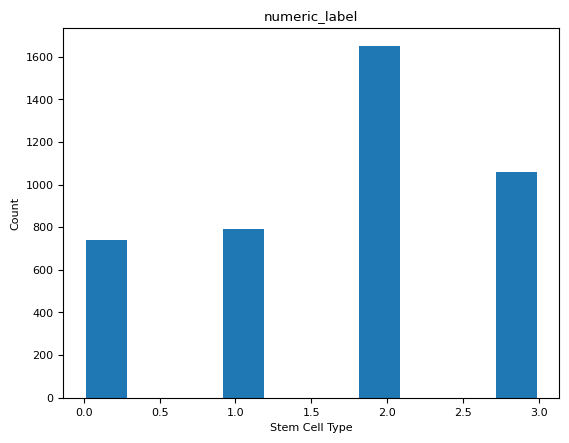

In [183]:
# # tcga_1st_round_combined.groupby(['numeric_label']).count()

# scs = ["hESC", "hMSC", "hUSC", "iPSC"]
# axarr = tcga_1st_round_combined.hist(column='numeric_label',  grid=False, zorder=2, rwidth=0.9, label=scs)

# # tcga_1st_round_combined.groupby(['numeric_label']).hist(alpha=0.7, label='numeric_label')

# for ax in axarr.flatten():
#     ax.set_xlabel("Stem Cell Type")
#     ax.set_ylabel("Count")

Reading combined file takes around 28 secs

In [93]:
combined_stmfr_tcga_labeled = pd.read_csv('/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Results/MLCB/combined_stmfr_tcga_labelled.csv')

In [82]:
combined_stmfr_tcga_labeled_df = combined_stmfr_tcga_labeled

In [95]:
tcga_labeled_df = combined_stmfr_tcga_labeled.loc[combined_stmfr_tcga_labeled['Unnamed: 0'].str.contains('TCGA')==True]
tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)


/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_804/1084887241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)


In [ ]:
# combined_stmfr_tcga_labeled_df.set_index(combined_stmfr_tcga_labeled_df['Unnamed: 0'], inplace=True)
# combined_stmfr_tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
combined_stmfr_tcga_labeled_df

In [ ]:
combined_stmfr_tcga_labeled_df.columns

In [ ]:
# tcga_labeled_df = combined_stmfr_tcga_labeled_df.loc[combined_stmfr_tcga_labeled_df['Unnamed: 0'].str.contains('TCGA')==True]
# tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
# tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
tcga_labeled_df

Train-test on various combination on STMFR and TCGA 

In [ ]:
# combined_stmfr_tcga_labeled_df
# df

In [ ]:
# df.shape, tcga_labeled_df.shape

# Train on STMFR and test on TCGA

# X_train = df.iloc[:, :-1]
# y_train = df['numeric_label']

# X_test = tcga_labeled_df.iloc[:, :-1]
# y_test = tcga_labeled_df['numeric_label']

# Train on TCGA and test on STMFR

# X_train = tcga_labeled_df.iloc[:, :-1]
# y_train = tcga_labeled_df['numeric_label']

# X_test = df.iloc[:, :-1]
# y_test = df['numeric_label']

# Train-test on combined STMFR+TCGA

# train, test = train_test_split(combined_stmfr_tcga_labeled_df, test_size=0.2, random_state=42, shuffle=True) 
# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# Train on combined STMFR (50%)+TCGA and test on 50% STMFR

# stmfr_train_df, stmfr_test_df = train_test_split(df, test_size=0.5, random_state=42, shuffle=True)

# train_df = pd.concat([tcga_labeled_df, stmfr_train_df], ignore_index=True)

# X_train = train_df.iloc[:, :-1]
# y_train = train_df['numeric_label']

# X_test = stmfr_test_df.iloc[:, :-1]
# y_test = stmfr_test_df['numeric_label']

# Train on combined STMFR+TCGA(50%) and test on 50% TCGA


tcga_train_df, tcga_test_df = train_test_split(tcga_labeled_df, test_size=0.5, random_state=42, shuffle=True)

train_df = pd.concat([df, tcga_train_df], ignore_index=True)

X_train = train_df.iloc[:, :-1]
y_train = train_df['numeric_label']

X_test = tcga_test_df.iloc[:, :-1]
y_test = tcga_test_df['numeric_label']



model = LogisticRegression(n_jobs=-1, max_iter=250)

# fit model
model.fit(X_train, y_train)
# make predictions
predictions = model.predict(X_test)

target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
# print(classification_report(y_test, predictions, target_names=target_names))

accuracy = accuracy_score(y_test, predictions)
# acc_list.append(accuracy)

b_accuracy = balanced_accuracy_score(y_test, predictions)
# b_acc_list.append(b_accuracy)

f1score = f1_score(y_test, predictions, average='weighted')
# f1_list.append(f1score)

precision = precision_score(y_test, predictions, average='weighted')
# prec_list.append(precision)

recall = recall_score(y_test, predictions, average='weighted')
# rec_list.append(recall)

print(accuracy, end='\t')
print(b_accuracy, end='\t')
print(f1score, end='\t')
print(precision, end='\t')
print(recall)



In [ ]:
x = tcga_labeled_df.iloc[:, :-1]
y = tcga_labeled_df['numeric_label']


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(x, y):
    
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(n_jobs=-1, max_iter=250)

    # fit model
    model.fit(X_train, y_train)
    # make predictions
    predictions = model.predict(X_test)

    target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    accuracy = accuracy_score(y_test, predictions)
    # acc_list.append(accuracy)

    b_accuracy = balanced_accuracy_score(y_test, predictions)
    # b_acc_list.append(b_accuracy)

    f1score = f1_score(y_test, predictions, average='weighted')
    # f1_list.append(f1score)

    precision = precision_score(y_test, predictions, average='weighted')
    # prec_list.append(precision)

    recall = recall_score(y_test, predictions, average='weighted')
    # rec_list.append(recall)

    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)



# pca_n_components=100
# pca=True

# train, test = train_test_split(tcga_labeled_df, test_size=0.1, random_state=42, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

# print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# if pca:
        
#     pca = PCA(n_components=pca_n_components)
#     X_train_pca = pca.fit_transform(X_train)
#     X_test_pca = pca.transform(X_test)
#     # tcga_pca = pca.transform(tcga)
    
#     model = LinearSVC(dual = False, max_iter=10000)
# else:
#     X_train_pca = X_train
#     X_test_pca = X_test
#     # tcga_pca = tcga

#     model = LinearSVC(dual = True, max_iter=10000)

 
# model.fit(X_train_pca, y_train)
# predictions = model.predict(X_test_pca)


# report = classification_report(y_test, predictions, output_dict=True)

# model_acc = accuracy_score(y_test, predictions, normalize=True)

In [ ]:
# model_acc

0.924190800681431

In [ ]:
# stmfr_pca = pca.transform(df.iloc[:, :-1])
# stmfr_predictions = model.predict(stmfr_pca)
# model_acc_stmfr = accuracy_score(df['numeric_label'], stmfr_predictions, normalize=True)

In [ ]:
# model_acc_stmfr

0.7975106253794778

In [18]:
# # def plot_comparison(accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5,
#                     combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
#                     fname):

#     sites = ("site 1", "site 2", "site 3", "site 4", "site 5")
#     accuracy = {
#         'Individual Model': (accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5),
#         'Combined Model': (combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5),
#     }


#     # print("\n\n",accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5, "\n\n",
#     #       combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
#     #       "\n\n")

#     x = np.arange(len(sites))  # the label locations
#     width = 0.25  # the width of the bars
#     multiplier = 0

#     fig, ax = plt.subplots(layout='constrained')

#     for attribute, measurement in accuracy.items():
#         # print("Printing:",attribute, measurement)
#         offset = width * multiplier
#         rects = ax.bar(x + offset, measurement, width, label=attribute)
#         ax.bar_label(rects, padding=0, rotation=60, fmt='{:,.2f}')
#         multiplier += 1

#     ax.set_ylabel('Accuracy')
#     # ax.set_title(title)
#     # ax.set_title('Model Performance RS = '+f'{random_state}')
#     ax.set_xticks(x + width, sites)

#     # ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#     ax.legend(loc='upper left', ncols=3)
#     ax.set_ylim(0.0, 1.2)

#     plt.show()

#     # fig_name = "random_state_"+f'{random_state}'+".png"
#     fig.savefig(fname)
#     plt.close(fig)

In [1]:
# !pwd

/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/gitrepo/model_agreement


In [ ]:
# derived_stmfr_test_df = pd.read_csv("../../Rounds/Reverse/s")